In [107]:
%load_ext autoreload
%autoreload 2


from __future__ import annotations

import numpy as np
from scipy import sparse
from scipy.sparse import linalg as spla
from math import floor
import math
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from tqdm import tqdm

%matplotlib inline


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Lower bounds and heuristic minima for the off-diagonal overlap moment 
$ \sum_{i \not =j} \bigl|<\psi_i|\psi_j>\bigr|^{2k}= N^{2}\mathcal E_k(\chi)-N$

# I ) d = 3, k = 3, 4 (General case "Theorem 5")

In [108]:
from Theorem5 import compute_WB_NB
from Heuristic_k_frame import optimize_kframe

$$ \lVert {g}_{k} \rVert_{2}^{2} \geq \Big(\frac{1}{\binom{d+k-1}{k}}+\Delta_{2}+ \frac{\Delta_{1}^{2}}{T} \Big) N^2 \label{Eq:StrongherWB}
$$
    

Where ${g}_{k}$ is the Gram matrix of the states (1 on diagonal elements) and

$\Delta_{k}:= \sum_{i=N+1}^{D(k,d)}\lambda_{i}^{k} $ with $\lambda_{1}\geq \lambda_{2}\geq ..\lambda_{D(k,d)}$ being the eigenvalues of $\tilde{I}_{\vee_{d}^{k}}^{\Gamma}$.

- The first term is the Welch bound
- T = N : the prevous version of the bound 
- T = D - M: the tightest bound, where M is the degeneracy of the smallest positive eigenvalue (most degeneracy for positive eigenvalue )

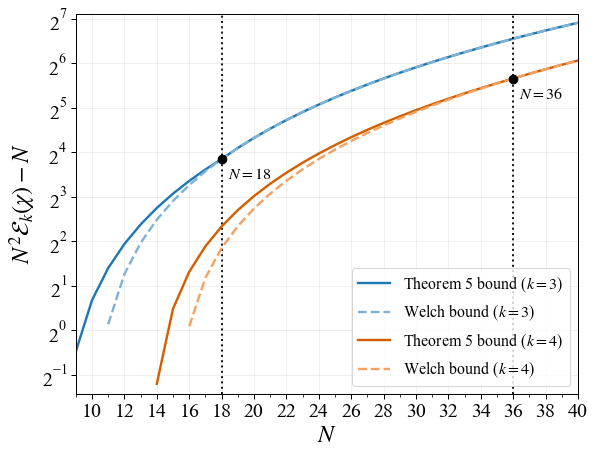

[Bounds] k=3: WB and NB meet at N = 18
[Bounds] k=4: WB and NB meet at N = 36


In [109]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, LogFormatterMathtext, MultipleLocator


plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "stix",
    "font.size": 16,
    "axes.labelsize": 24,
    "axes.titlesize": 18,
    "legend.fontsize": 16,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "axes.linewidth": 1.0,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


# Color families 
colors = {
    3: {"NB": "#1f77b4", "WB": "#7fb3d5", "HEU": "#0b3c6d"},
    4: {"NB": "#d55e00", "WB": "#f4a261", "HEU": "#7f2704"},
}

# Fixed parameters
d = 3
k_values = [3, 4]
N_min, N_max = 9, 40
N_values = np.arange(N_min, N_max + 1)
tol = 1e-10

# Caches to reuse in cell 3
bounds_data = {}
meeting_info = {}
all_positive_y_bounds = []

# ---- Compute WB/NB off-diagonal only ----
for k in k_values:
    WB_arr = np.empty(len(N_values), dtype=float)
    NB_arr = np.empty(len(N_values), dtype=float)

    for i, N in enumerate(N_values):
        WB, NB, _ = compute_WB_NB(d, k, int(N))
        WB_arr[i] = WB - N
        NB_arr[i] = NB - N

    WB_plot = np.where(WB_arr > 0, WB_arr, np.nan)
    NB_plot = np.where(NB_arr > 0, NB_arr, np.nan)

    bounds_data[k] = {
        "WB_arr": WB_arr,
        "NB_arr": NB_arr,
        "WB_plot": WB_plot,
        "NB_plot": NB_plot,
    }

    all_positive_y_bounds.extend(WB_plot[np.isfinite(WB_plot)])
    all_positive_y_bounds.extend(NB_plot[np.isfinite(NB_plot)])

    # first meeting of WB and NB
    meet_indices = np.where(np.abs(WB_arr - NB_arr) <= tol)[0]
    if len(meet_indices) > 0:
        i0 = int(meet_indices[0])
        meeting_info[k] = ("meet", int(N_values[i0]), float(WB_arr[i0]))
    else:
        i0 = int(np.argmin(np.abs(WB_arr - NB_arr)))
        meeting_info[k] = ("closest", int(N_values[i0]), float(np.abs(WB_arr[i0] - NB_arr[i0])))

# ---- Bounds-only plot ----
plt.close("all")
fig, ax = plt.subplots(figsize=(9, 7))

for k in k_values:
    ax.plot(
        N_values, bounds_data[k]["NB_plot"],
        linestyle="-", linewidth=2.4, color=colors[k]["NB"],
        label=fr"Theorem 5 bound ($k={k}$)"
    )
    ax.plot(
        N_values, bounds_data[k]["WB_plot"],
        linestyle="--", linewidth=2.4, color=colors[k]["WB"],
        label=fr"Welch bound ($k={k}$)"
    )

    info = meeting_info[k]
    if info[0] == "meet":
        _, N_meet, y_meet = info
        if y_meet > 0:
            ax.scatter(N_meet, y_meet, s=75, color="black", zorder=6)
            ax.axvline(N_meet, linestyle=":", linewidth=2.0, color="black", alpha=0.9)
            ax.annotate(fr"$N={N_meet}$", xy=(N_meet, y_meet),
                        xytext=(6, -20), textcoords="offset points", fontsize=16)

ax.set_xlim(N_min, N_max)
ax.xaxis.set_major_locator(MultipleLocator(2))
ax.xaxis.set_minor_locator(MultipleLocator(1))

ax.set_yscale("log", base=2)
ax.yaxis.set_major_locator(LogLocator(base=2))
ax.yaxis.set_major_formatter(LogFormatterMathtext(base=2))

if len(all_positive_y_bounds) > 0:
    ymin = np.nanmin(all_positive_y_bounds)
    ymax = np.nanmax(all_positive_y_bounds)
    ax.set_ylim(ymin * 0.85, ymax * 1.15)

ax.tick_params(axis="both", which="major", direction="out", length=5, width=1.0)
ax.tick_params(axis="both", which="minor", direction="out", length=3, width=0.8)

ax.set_xlabel(r"$N$")
ax.set_ylabel(r"$N^{2}\mathcal{E}_{k}(\chi)-N$")
ax.grid(True, which="major", alpha=0.25)
ax.legend(frameon=True, ncol=1)

fig.savefig("WB_NB_only_d3_k3_k4.pdf", bbox_inches="tight")
fig.savefig("WB_NB_only_d3_k3_k4.png", dpi=300, bbox_inches="tight")
plt.show()

for k in k_values:
    info = meeting_info[k]
    if info[0] == "meet":
        print(f"[Bounds] k={k}: WB and NB meet at N = {info[1]}")
    else:
        print(f"[Bounds] k={k}: no exact meet within tol={tol}; closest at N = {info[1]} (|WB-NB|={info[2]:.3e})")


## Heuristic

In [17]:
import numpy as np
from tqdm.auto import tqdm


n_restarts = 1 #10
base_seed = 42
fix_first = True

# Store only off-diagonal heuristic: FP_k - N
heuristics_data = {}     # k -> array(len(N_values))
success_flags = {}       # optional: k -> 0/1 array(len(N_values))

for k in k_values:
    heur_arr = np.full(len(N_values), np.nan, dtype=float)
    succ_arr = np.zeros(len(N_values), dtype=float)

    for idx, N in enumerate(tqdm(N_values, desc=f"Heuristic sweep d={d}, k={k}")):
        fp_heuristic, states_opt, res = optimize_kframe(
            d=d, N=int(N), k=int(k),
            n_restarts=n_restarts,
            seed=base_seed + 1000*k + idx,
            fix_first=fix_first
        )

        heur_arr[idx] = fp_heuristic - N          # <-- off-diagonal only
        succ_arr[idx] = 1.0 if getattr(res, "success", False) else 0.0

    heuristics_data[k] = heur_arr
    success_flags[k] = succ_arr

    # Save per-k (optional)
    np.save(f"heur_offdiag_d{d}_k{k}.npy", heur_arr)
    np.save(f"heur_success_d{d}_k{k}.npy", succ_arr)
    print(f"Saved: heur_offdiag_d{d}_k{k}.npy")

# Save combined (optional)
np.savez_compressed(
    f"heur_offdiag_d{d}_k3_k4.npz",
    d=np.array([d]),
    N_values=np.array(N_values),
    heur_k3=heuristics_data[3],
    heur_k4=heuristics_data[4],
    success_k3=success_flags[3],
    success_k4=success_flags[4],
)
print(f"Saved combined: heur_offdiag_d{d}_k3_k4.npz")


Heuristic sweep d=3, k=3:   0%|          | 0/32 [00:00<?, ?it/s]

Saved: heur_offdiag_d3_k3.npy


Heuristic sweep d=3, k=4:   0%|          | 0/32 [00:00<?, ?it/s]

Saved: heur_offdiag_d3_k4.npy
Saved combined: heur_offdiag_d3_k3_k4.npz


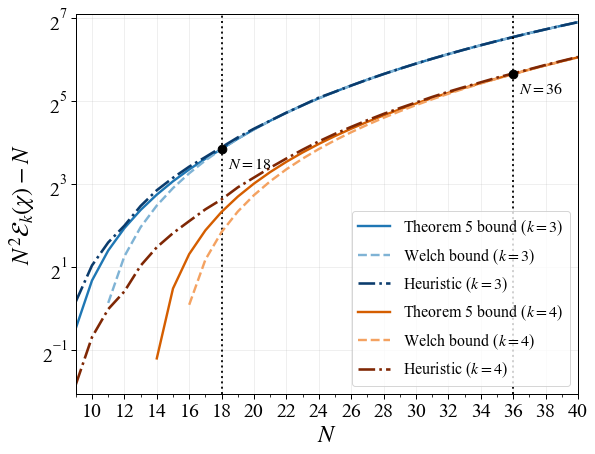

[Full] k=3: WB and NB meet at N = 18
[Full] k=4: WB and NB meet at N = 36


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, LogFormatterMathtext, MultipleLocator

# Needs: bounds_data + meeting_info (cell 1), heuristics_data (cell 2), colors, N_values, ...

plt.close("all")
fig, ax = plt.subplots(figsize=(9, 7))

all_positive_y_full = list(all_positive_y_bounds)

for k in k_values:
    WB_plot = bounds_data[k]["WB_plot"]
    NB_plot = bounds_data[k]["NB_plot"]

    heur_arr = np.asarray(heuristics_data[k], dtype=float)
    heur_plot = np.where(heur_arr > 0, heur_arr, np.nan)

    all_positive_y_full.extend(heur_plot[np.isfinite(heur_plot)])

    # Bounds
    ax.plot(
        N_values, NB_plot,
        linestyle="-", linewidth=2.4, color=colors[k]["NB"],
        label=fr"Theorem 5 bound ($k={k}$)"
    )
    ax.plot(
        N_values, WB_plot,
        linestyle="--", linewidth=2.4, color=colors[k]["WB"],
        label=fr"Welch bound ($k={k}$)"
    )

    # Heuristic off-diagonal
    ax.plot(
        N_values, heur_plot,
        linestyle="-.", linewidth=2.6, color=colors[k]["HEU"],
        label=fr"Heuristic ($k={k}$)"
    )

    # Annotate WB/NB meeting
    info = meeting_info[k]
    if info[0] == "meet":
        _, N_meet, y_meet = info
        if y_meet > 0:
            ax.scatter(N_meet, y_meet, s=75, color="black", zorder=6)
            ax.axvline(N_meet, linestyle=":", linewidth=2.0, color="black", alpha=0.9)
            ax.annotate(fr"$N={N_meet}$", xy=(N_meet, y_meet),
                        xytext=(6, -20), textcoords="offset points", fontsize=16)

ax.set_xlim(N_min, N_max)
ax.xaxis.set_major_locator(MultipleLocator(2))
ax.xaxis.set_minor_locator(MultipleLocator(1))

ax.set_yscale("log", base=2)
ax.yaxis.set_major_locator(LogLocator(base=2))
ax.yaxis.set_major_formatter(LogFormatterMathtext(base=2))

if len(all_positive_y_full) > 0:
    ymin = np.nanmin(all_positive_y_full)
    ymax = np.nanmax(all_positive_y_full)
    ax.set_ylim(ymin * 0.85, ymax * 1.15)

ax.tick_params(axis="both", which="major", direction="out", length=5, width=1.0)
ax.tick_params(axis="both", which="minor", direction="out", length=3, width=0.8)

ax.set_xlabel(r"$N$")
ax.set_ylabel(r"$N^{2}\mathcal{E}_{k}(\chi)-N$")
ax.grid(True, which="major", alpha=0.25)
ax.legend(frameon=True, ncol=1)

fig.savefig("WB_NB_HEU_d3_k3_k4.pdf", bbox_inches="tight")
fig.savefig("WB_NB_HEU_d3_k3_k4.png", dpi=300, bbox_inches="tight")
plt.show()

for k in k_values:
    info = meeting_info[k]
    if info[0] == "meet":
        print(f"[Full] k={k}: WB and NB meet at N = {info[1]}")
    else:
        print(f"[Full] k={k}: no exact meet within tol={tol}; closest at N = {info[1]} (|WB-NB|={info[2]:.3e})")


# II ) MUBs
# $k=3$ in the $2$-design regime with $N=d(d+1)$: ( "Theorem 6")

In [25]:
from Theorem6 import our_bound, Welch_bound

k = 3
d_min = 2        
d_max = 30

d_values = list(range(d_min, d_max + 1))
new_vals  = []
welch_vals  = []
for d in tqdm(d_values):
    N = d *(d+1)
    nb = our_bound(k, d, N)
    wb  = Welch_bound(k, d, N)

    new_vals.append(float(nb-N))
    welch_vals.append(float(wb-N))


100%|████████████████████████████████████████| 29/29 [00:00<00:00, 53512.90it/s]


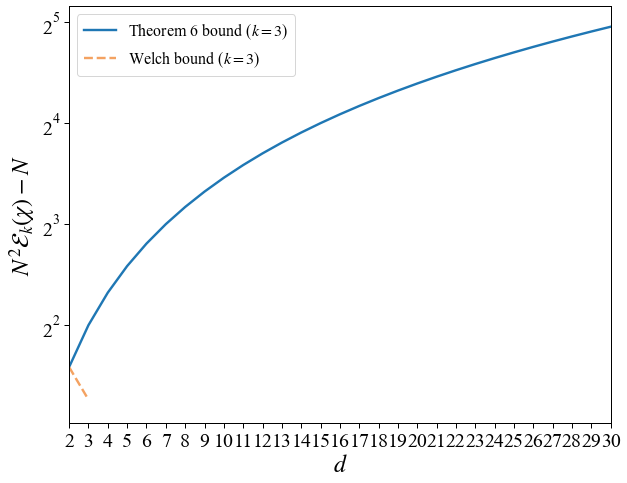

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, LogFormatterMathtext, MultipleLocator


plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "stix",
    "font.size": 16,
    "axes.labelsize": 24,
    "axes.titlesize": 18,
    "legend.fontsize": 16,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "axes.linewidth": 1.0,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


d_curve = np.asarray(d_values, dtype=float)
new = np.asarray(new_vals, dtype=float)
welch = np.asarray(welch_vals, dtype=float)

# For log scale safety
new_plot = np.where(new > 0, new, np.nan)
welch_plot = np.where(welch > 0, welch, np.nan)

# Plot
plt.close("all")
fig, ax = plt.subplots(figsize=(9, 7))

ax.plot(
    d_curve, new_plot,
    label=r"Theorem 6 bound ($k=3$)",
    linewidth=2.4, linestyle="-",
    color="#1f77b4"
)
ax.plot(
    d_curve, welch_plot,
    label=r"Welch bound ($k=3$)",
    linewidth=2.4, linestyle="--",
    color="#f4a261"
)


ax.set_yscale("log", base=2)
ax.yaxis.set_major_locator(LogLocator(base=2))
ax.yaxis.set_major_formatter(LogFormatterMathtext(base=2))


xmin = int(np.floor(np.nanmin(d_curve)))
xmax = int(np.ceil(np.nanmax(d_curve)))
ax.set_xlim(xmin, xmax)
ax.xaxis.set_major_locator(MultipleLocator(1))

# y-limits from positive data
all_positive = np.r_[new_plot[np.isfinite(new_plot)],
                     welch_plot[np.isfinite(welch_plot)]]
if all_positive.size > 0:
    ax.set_ylim(np.nanmin(all_positive) * 0.85, np.nanmax(all_positive) * 1.15)

# Tick style
ax.tick_params(axis="both", which="major", direction="out", length=5, width=1.0)

# Labels
ax.set_xlabel(r"$d$")
ax.set_ylabel(r"$N^{2}\mathcal{E}_{k}(\chi)-N$")

ax.legend(frameon=True, ncol=1)

fig.tight_layout()
plt.show()


## Heuristic for d from 2 to 8
### Here we Optimize $\mathcal{E}_{k}(\chi)$

In [50]:
from Heuristic_MUBs import search_MUBs_with_2design_penalty, haar_Ek
import torch

import numpy as np
import torch
import math

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

d_h_max = 8
d_points = range(2, d_h_max + 1)   # 2,3,4,5,6,7

rows = []  # each row: [d, E2, E2_target, E2_gap, E3, E3_target, E3_gap, |E3_gap|, f]

for d in d_points:
    print(f"\nRunning d={d}")
    best = search_MUBs_with_2design_penalty(
        d=d,
        steps=15000,
        lr=0.03,
        restarts=12,
        lam=800.0,
        seed=42,
        device=device,
        print_every=3000,
    )

    E2_target = haar_Ek(d, 2)
    E3_target = 1.0 / (d * d)
    E2_gap = best["E2"] - E2_target
    E3_gap = best["E3"] - E3_target

    rows.append([
        d,
        best["E2"], E2_target, E2_gap,
        best["E3"], E3_target, E3_gap, abs(E3_gap),
        best["f"]
    ])

results = np.array(rows, dtype=float)

# optional save
np.save("heuristic_results_d2_to_d7.npy", results)

print("\nDone. results shape:", results.shape)
print("Columns: d, E2, E2_target, E2_gap, E3, E3_target, E3_gap, |E3_gap|, f")
print(results)


Device: cpu

Running d=2
[d=2 restart 1/12 step     0] E2=3.7352356315e-01 (Haar 3.3333333333e-01, diff 4.019e-02) | E3=3.1028535962e-01 (target 2.5000000000e-01, diff 6.029e-02, |diff| 6.029e-02) | f=1.352e+00
--> Early stop at restart 1, step 139: |E3 - target_E3| = 0.000e+00 <= 1.0e-08

BEST RESULT
  d=2
  E2=3.333333432674e-01  (Haar 3.333333333333e-01)  diff=9.934e-09
  E3=2.500000000000e-01  (target 2.500000000000e-01)  diff=0.000e+00
  |E3-target|=0.000e+00
  f =0.000e+00
  Early-stop criterion met: |E3-target_E3| <= 1.0e-08

Running d=3
[d=3 restart 1/12 step     0] E2=2.0701961219e-01 (Haar 1.6666666667e-01, diff 4.035e-02) | E3=1.5590484440e-01 (target 1.1111111111e-01, diff 4.479e-02, |diff| 4.479e-02) | f=1.347e+00
--> Early stop at restart 1, step 263: |E3 - target_E3| = 8.278e-10 <= 1.0e-08

BEST RESULT
  d=3
  E2=1.666666865349e-01  (Haar 1.666666666667e-01)  diff=1.987e-08
  E3=1.111111268401e-01  (target 1.111111111111e-01)  diff=1.573e-08
  |E3-target|=1.573e-08
  f =

[d=6 restart 6/12 step  9000] E2=4.9676861614e-02 (Haar 4.7619047619e-02, diff 2.058e-03) | E3=2.8649285436e-02 (target 2.7777777778e-02, diff 8.715e-04, |diff| 8.715e-04) | f=4.259e-03
[d=6 restart 6/12 step 12000] E2=4.9677003175e-02 (Haar 4.7619047619e-02, diff 2.058e-03) | E3=2.8649281710e-02 (target 2.7777777778e-02, diff 8.715e-04, |diff| 8.715e-04) | f=4.260e-03
[d=6 restart 6/12 step 14999] E2=4.9676410854e-02 (Haar 4.7619047619e-02, diff 2.057e-03) | E3=2.8648991138e-02 (target 2.7777777778e-02, diff 8.712e-04, |diff| 8.712e-04) | f=4.257e-03
[d=6 restart 7/12 step     0] E2=6.4715906978e-02 (Haar 4.7619047619e-02, diff 1.710e-02) | E3=3.9277013391e-02 (target 2.7777777778e-02, diff 1.150e-02, |diff| 1.150e-02) | f=2.453e-01
[d=6 restart 7/12 step  3000] E2=4.9902822822e-02 (Haar 4.7619047619e-02, diff 2.284e-03) | E3=2.8851578012e-02 (target 2.7777777778e-02, diff 1.074e-03, |diff| 1.074e-03) | f=5.246e-03
[d=6 restart 7/12 step  6000] E2=4.9902822822e-02 (Haar 4.7619047619e-

[d=8 restart 1/12 step  6000] E2=3.0090305954e-02 (Haar 2.7777777778e-02, diff 2.313e-03) | E3=1.6486059874e-02 (target 1.5625000000e-02, diff 8.611e-04, |diff| 8.611e-04) | f=5.139e-03
[d=8 restart 1/12 step  9000] E2=3.0090337619e-02 (Haar 2.7777777778e-02, diff 2.313e-03) | E3=1.6486097127e-02 (target 1.5625000000e-02, diff 8.611e-04, |diff| 8.611e-04) | f=5.139e-03
[d=8 restart 1/12 step 12000] E2=3.0090468004e-02 (Haar 2.7777777778e-02, diff 2.313e-03) | E3=1.6486151144e-02 (target 1.5625000000e-02, diff 8.612e-04, |diff| 8.612e-04) | f=5.140e-03
[d=8 restart 1/12 step 14999] E2=3.0090328306e-02 (Haar 2.7777777778e-02, diff 2.313e-03) | E3=1.6486132517e-02 (target 1.5625000000e-02, diff 8.611e-04, |diff| 8.611e-04) | f=5.139e-03
[d=8 restart 2/12 step     0] E2=3.8880769163e-02 (Haar 2.7777777778e-02, diff 1.110e-02) | E3=2.1622085944e-02 (target 1.5625000000e-02, diff 5.997e-03, |diff| 5.997e-03) | f=1.046e-01
[d=8 restart 2/12 step  3000] E2=2.9976403341e-02 (Haar 2.7777777778e-

[d=8 restart 8/12 step 14999] E2=3.0034637079e-02 (Haar 2.7777777778e-02, diff 2.257e-03) | E3=1.6468320042e-02 (target 1.5625000000e-02, diff 8.433e-04, |diff| 8.433e-04) | f=4.918e-03
[d=8 restart 9/12 step     0] E2=3.9063736796e-02 (Haar 2.7777777778e-02, diff 1.129e-02) | E3=2.1719446406e-02 (target 1.5625000000e-02, diff 6.094e-03, |diff| 6.094e-03) | f=1.080e-01
[d=8 restart 9/12 step  3000] E2=3.0002985150e-02 (Haar 2.7777777778e-02, diff 2.225e-03) | E3=1.6453107819e-02 (target 1.5625000000e-02, diff 8.281e-04, |diff| 8.281e-04) | f=4.789e-03
[d=8 restart 9/12 step  6000] E2=3.0005302280e-02 (Haar 2.7777777778e-02, diff 2.228e-03) | E3=1.6454096884e-02 (target 1.5625000000e-02, diff 8.291e-04, |diff| 8.291e-04) | f=4.799e-03
[d=8 restart 9/12 step  9000] E2=3.0002996325e-02 (Haar 2.7777777778e-02, diff 2.225e-03) | E3=1.6453094780e-02 (target 1.5625000000e-02, diff 8.281e-04, |diff| 8.281e-04) | f=4.789e-03
[d=8 restart 9/12 step 12000] E2=3.0003050342e-02 (Haar 2.7777777778e-

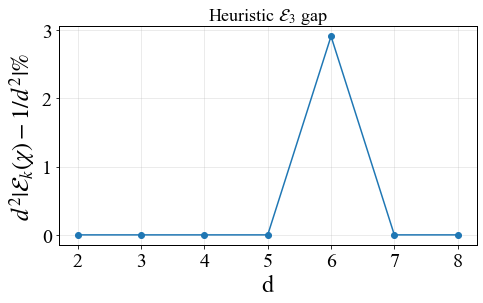

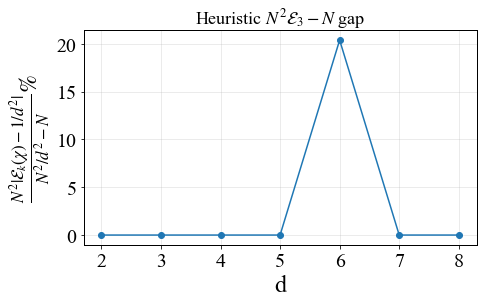

In [99]:
import matplotlib.pyplot as plt
import numpy as np

# load if needed:
# results = np.load("heuristic_results_d2_to_d7.npy")

d = results[:, 0]
E3_abs_gap = results[:, 7]

plot = []
plot_2 = []
for i in range(len(d)):
    p = 100*E3_abs_gap[i]*(d[i]**2) #normalize to 1/d^2
    plot.append(p)
    
    N = d[i]*(d[i]+1)
    p2 = 100*(N**2*E3_abs_gap[i]) / (N**2/d[i]**2 - N)
    plot_2.append(p2)

plt.figure(figsize=(7, 4.5))
plt.plot(d, plot, marker="o")
#plt.yscale("log")
plt.xlabel("d")
plt.ylabel(r"$d^2 |\mathcal{E}_{k}(\chi) - 1/d^2| \%$")
plt.title("Heuristic $\mathcal{E}_3$ gap")
plt.grid(True, which="both", alpha=0.3)
plt.xticks(d.astype(int))
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4.5))
plt.plot(d, plot_2, marker="o")
#plt.yscale("log")
plt.xlabel("d")
plt.ylabel(r"$\frac{N^2 |\mathcal{E}_{k}(\chi) - 1/d^2|}{N^2/d^2 - N} \%$")
plt.title("Heuristic $N^2\mathcal{E}_3 - N$ gap")
plt.grid(True, which="both", alpha=0.3)
plt.xticks(d.astype(int))
plt.tight_layout()
plt.show()



In [102]:
d_h = results[:, 0]
E3_h = results[:, 4]
N_vals = np.array([di * (di + 1) for di in d_h], dtype=float)

overlap_moment_h = []
for i in range(len(d_h)):
    N = d[i]*(d[i]+1)
    overlap_moment_h.append(E3_h[i]* (N**2))
overlap_moment_h

[np.float64(9.0),
 np.float64(16.0000022649765),
 np.float64(25.000005960464478),
 np.float64(36.000002548098564),
 np.float64(50.426417358219624),
 np.float64(64.00003957748413),
 np.float64(81.00005793571472)]

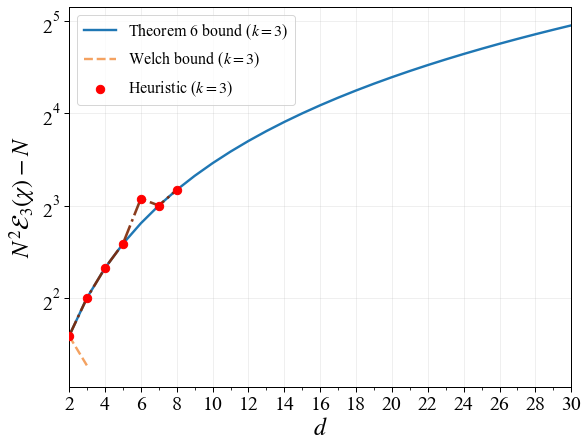

In [106]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, LogFormatterMathtext, MultipleLocator


plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "stix",
    "font.size": 16,
    "axes.labelsize": 24,
    "axes.titlesize": 18,
    "legend.fontsize": 16,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "axes.linewidth": 1.0,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


d_curve = np.asarray(d_values, dtype=float)
new = np.asarray(new_vals, dtype=float)
welch = np.asarray(welch_vals, dtype=float)


# off-diag
heuristic_nor = overlap_moment_h - N_vals

# For log scale safety
new_plot = np.where(new > 0, new, np.nan)
welch_plot = np.where(welch > 0, welch, np.nan)
heur_plot = np.where(heuristic_nor > 0, heuristic_nor, np.nan)

# -----------------------------
# Plot
# -----------------------------
plt.close("all")
fig, ax = plt.subplots(figsize=(9, 7))

# Keep colors as you requested
ax.plot(
    d_curve, new_plot,
    label=r"Theorem 6 bound ($k=3$)",
    linewidth=2.4, linestyle="-",
    color="#1f77b4"
)
ax.plot(
    d_curve, welch_plot,
    label=r"Welch bound ($k=3$)",
    linewidth=2.4, linestyle="--",
    color="#f4a261"
)

# Heuristic points + connecting line
ax.scatter(
    d_h, heur_plot,
    marker="o", s=70, zorder=10,
    color="red",
    label=r"Heuristic ($k=3$)"
)
ax.plot(
    d_h, heur_plot,
    linestyle="-.", linewidth=2.6, alpha=0.9,
    color="#7f2704"
)

# -----------------------------
# Axis formatting (match first plot)
# -----------------------------
ax.set_yscale("log", base=2)
ax.yaxis.set_major_locator(LogLocator(base=2))
ax.yaxis.set_major_formatter(LogFormatterMathtext(base=2))

# x ticks every 2 (and minor every 1)
xmin = int(np.floor(np.nanmin(np.r_[d_curve, d_h])))
xmax = int(np.ceil(np.nanmax(np.r_[d_curve, d_h])))
ax.set_xlim(xmin, xmax)
ax.xaxis.set_major_locator(MultipleLocator(2))
ax.xaxis.set_minor_locator(MultipleLocator(1))

# Optional y-limits from positive data
all_positive = np.r_[new_plot[np.isfinite(new_plot)],
                     welch_plot[np.isfinite(welch_plot)],
                     heur_plot[np.isfinite(heur_plot)]]
if all_positive.size > 0:
    ax.set_ylim(np.nanmin(all_positive) * 0.85, np.nanmax(all_positive) * 1.15)

# Tick style like first plot
ax.tick_params(axis="both", which="major", direction="out", length=5, width=1.0)
ax.tick_params(axis="both", which="minor", direction="out", length=3, width=0.8)

ax.set_xlabel(r"$d$")
ax.set_ylabel(r"$N^{2}\mathcal{E}_{3}(\chi)-N$")

# Major grid only, same feel as first plot
ax.grid(True, which="major", alpha=0.25)

ax.legend(frameon=True, ncol=1)

fig.savefig("MUB_Plot.pdf", bbox_inches="tight")
fig.savefig("MUB_Plot.png", dpi=300, bbox_inches="tight")
plt.show()
